#  📊 NÚMEROS ÍNDICES 📈
## Definición, tipos, fórmulas y el IPC con ponderaciones vigentes 2026 · Base 2025

In [ ]:
pip install pandas numpy matplotlib tabulate

CÁLCULO DE NÚMEROS ÍNDICES - EJEMPLO PRÁCTICO

📊 DATOS DE PARTIDA:
--------------------------------------------------
+----+------------+---------------+-----------------+-----------------+-------------------+
|    | Producto   |   Precio_base |   Cantidad_base |   Precio_actual |   Cantidad_actual |
+====+============+===============+=================+=================+===================+
|  0 | Pan        |          1.00 |             100 |            1.30 |               110 |
+----+------------+---------------+-----------------+-----------------+-------------------+
|  1 | Leche      |          1.20 |              50 |            1.50 |                45 |
+----+------------+---------------+-----------------+-----------------+-------------------+
|  2 | Huevos     |          2.00 |              30 |            2.20 |                35 |
+----+------------+---------------+-----------------+-----------------+-------------------+

Año base: 2020 | Año actual: 2024

🧮 CÁLCULOS PREVIOS

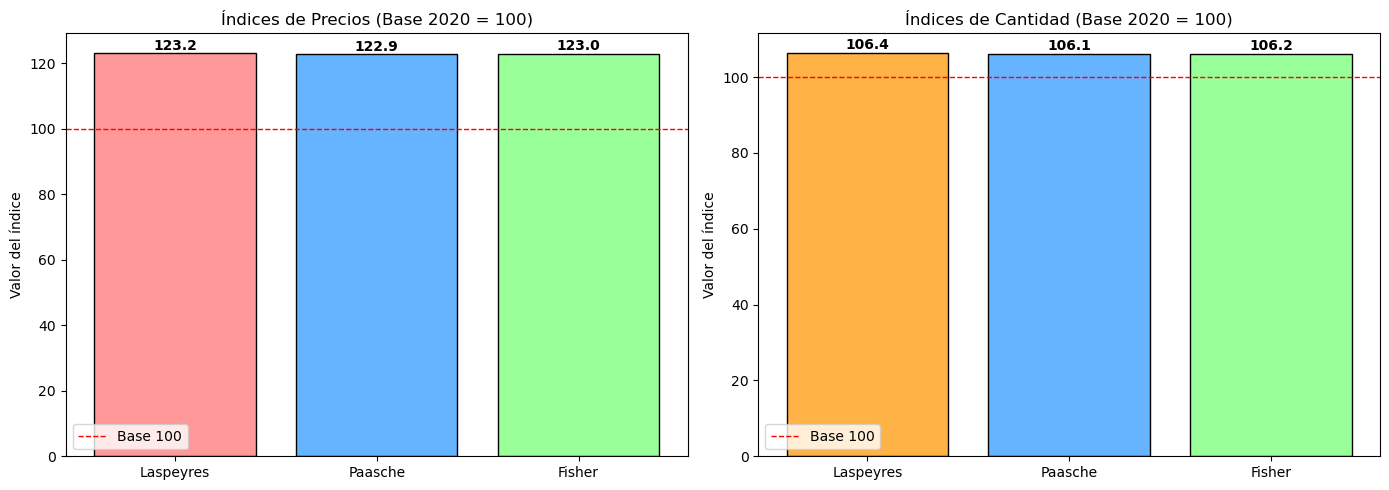


🏠 8. EJEMPLO SIMPLIFICADO DEL IPC (con ponderaciones)

📊 Ponderaciones normalizadas (simuladas):
   Pan: 0.347 (34.7%)
   Leche: 0.347 (34.7%)
   Huevos: 0.306 (30.6%)

📌 IPC = ∑ (ponderación_i × índice_simple_precio_i)
   IPC = 122.14
   ▶️ Interpretación: Los precios han subido un 22.1% de media ponderada

🎯 COMPARATIVA: Índice de Valor vs IPC vs Fisher

📊 RESULTADOS CLAVE:
   • Índice de Valor (gasto total): 130.68 → +30.7%
   • IPC ponderado (solo precios):  122.14 → +22.1%
   • Fisher precios (ideal):        123.02 → +23.0%
   
💡 INTERPRETACIÓN:
   El gasto total (valor) ha subido más que los precios porque también
   han cambiado las cantidades consumidas. El IPC mide SOLO el efecto
   precios, manteniendo fija la cesta (Laspeyres). El Fisher corrige
   el sesgo de sustitución.


✅ FIN DEL EJEMPLO


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tabulate import tabulate

# ============================================================
# EJEMPLO COMPLETO DE CÁLCULO DE NÚMEROS ÍNDICES EN PYTHON
# ============================================================

print("="*80)
print("CÁLCULO DE NÚMEROS ÍNDICES - EJEMPLO PRÁCTICO")
print("="*80)

# ------------------------------------------------------------
# 1. DATOS DE EJEMPLO: 3 productos, 2 períodos (año base y año actual)
# ------------------------------------------------------------
print("\n📊 DATOS DE PARTIDA:")
print("-"*50)

# Creamos un DataFrame con los datos
datos = pd.DataFrame({
    'Producto': ['Pan', 'Leche', 'Huevos'],
    'Precio_base': [1.0, 1.2, 2.0],      # p₀ (año 2020)
    'Cantidad_base': [100, 50, 30],       # q₀ (año 2020)
    'Precio_actual': [1.3, 1.5, 2.2],     # pₜ (año 2024)
    'Cantidad_actual': [110, 45, 35]       # qₜ (año 2024)
})

print(tabulate(datos, headers='keys', tablefmt='grid', floatfmt='.2f'))
print("\nAño base: 2020 | Año actual: 2024")

# ------------------------------------------------------------
# 2. CÁLCULOS PREVIOS: Gastos y valores totales
# ------------------------------------------------------------
print("\n" + "="*80)
print("🧮 CÁLCULOS PREVIOS")
print("="*80)

# Gastos en cada período
datos['Gasto_base'] = datos['Precio_base'] * datos['Cantidad_base']
datos['Gasto_actual'] = datos['Precio_actual'] * datos['Cantidad_actual']
datos['Gasto_hibrido1'] = datos['Precio_actual'] * datos['Cantidad_base']  # pₜ·q₀
datos['Gasto_hibrido2'] = datos['Precio_base'] * datos['Cantidad_actual']  # p₀·qₜ

print("\n📋 Tabla completa de gastos:")
print(tabulate(datos, headers='keys', tablefmt='grid', floatfmt='.2f'))

# Totales
total_gasto_base = datos['Gasto_base'].sum()
total_gasto_actual = datos['Gasto_actual'].sum()
total_paq0 = datos['Gasto_hibrido1'].sum()  # ∑ pₜ·q₀
total_p0qa = datos['Gasto_hibrido2'].sum()  # ∑ p₀·qₜ

print(f"\n📈 Totales:")
print(f"   Gasto total año base (∑ p₀·q₀): {total_gasto_base:.2f} €")
print(f"   Gasto total año actual (∑ pₜ·qₜ): {total_gasto_actual:.2f} €")
print(f"   ∑ pₜ·q₀ (gasto si compro cesta base a precios actuales): {total_paq0:.2f} €")
print(f"   ∑ p₀·qₜ (gasto si compro cesta actual a precios base): {total_p0qa:.2f} €")

# ------------------------------------------------------------
# 3. ÍNDICES SIMPLES (para cada producto)
# ------------------------------------------------------------
print("\n" + "="*80)
print("📏 1. ÍNDICES SIMPLES")
print("="*80)

datos['Indice_precio_simple'] = (datos['Precio_actual'] / datos['Precio_base'] * 100)
datos['Indice_cantidad_simple'] = (datos['Cantidad_actual'] / datos['Cantidad_base'] * 100)

print("\n📊 Índices simples por producto:")
print(tabulate(datos[['Producto', 'Precio_base', 'Precio_actual', 'Indice_precio_simple',
                      'Cantidad_base', 'Cantidad_actual', 'Indice_cantidad_simple']], 
               headers='keys', tablefmt='grid', floatfmt='.2f'))

# ------------------------------------------------------------
# 4. ÍNDICES COMPLEJOS DE PRECIOS
# ------------------------------------------------------------
print("\n" + "="*80)
print("⚖️ 2. ÍNDICES COMPLEJOS DE PRECIOS")
print("="*80)

# Índice de Laspeyres de Precios
laspeyres_precios = (total_paq0 / total_gasto_base) * 100

# Índice de Paasche de Precios
paasche_precios = (total_gasto_actual / total_p0qa) * 100

# Índice de Fisher de Precios
fisher_precios = np.sqrt(laspeyres_precios * paasche_precios)

print(f"\n📌 Laspeyres (precios): Lₚ = (∑ pₜ·q₀ / ∑ p₀·q₀) × 100")
print(f"   Lₚ = ({total_paq0:.2f} / {total_gasto_base:.2f}) × 100 = {laspeyres_precios:.2f}")
print(f"   ▶️ La cesta de 2020 cuesta hoy un {laspeyres_precios-100:.1f}% más")

print(f"\n📌 Paasche (precios): Pₚ = (∑ pₜ·qₜ / ∑ p₀·qₜ) × 100")
print(f"   Pₚ = ({total_gasto_actual:.2f} / {total_p0qa:.2f}) × 100 = {paasche_precios:.2f}")
print(f"   ▶️ La cesta actual cuesta un {paasche_precios-100:.1f}% más que en 2020")

print(f"\n📌 Fisher (precios): Fₚ = √(Lₚ × Pₚ)")
print(f"   Fₚ = √({laspeyres_precios:.2f} × {paasche_precios:.2f}) = {fisher_precios:.2f}")

# ------------------------------------------------------------
# 5. ÍNDICES COMPLEJOS DE CANTIDAD
# ------------------------------------------------------------
print("\n" + "="*80)
print("📦 3. ÍNDICES COMPLEJOS DE CANTIDAD")
print("="*80)

# Laspeyres de Cantidad (pondera con precios base)
laspeyres_cantidad = (total_p0qa / total_gasto_base) * 100

# Paasche de Cantidad (pondera con precios actuales)
paasche_cantidad = (total_gasto_actual / total_paq0) * 100

# Fisher de Cantidad
fisher_cantidad = np.sqrt(laspeyres_cantidad * paasche_cantidad)

print(f"\n📌 Laspeyres (cantidad): L_q = (∑ qₜ·p₀ / ∑ q₀·p₀) × 100")
print(f"   L_q = ({total_p0qa:.2f} / {total_gasto_base:.2f}) × 100 = {laspeyres_cantidad:.2f}")
print(f"   ▶️ La cantidad ha variado un {laspeyres_cantidad-100:.1f}% (a precios base)")

print(f"\n📌 Paasche (cantidad): P_q = (∑ qₜ·pₜ / ∑ q₀·pₜ) × 100")
print(f"   P_q = ({total_gasto_actual:.2f} / {total_paq0:.2f}) × 100 = {paasche_cantidad:.2f}")
print(f"   ▶️ La cantidad ha variado un {paasche_cantidad-100:.1f}% (a precios actuales)")

print(f"\n📌 Fisher (cantidad): F_q = √(L_q × P_q)")
print(f"   F_q = √({laspeyres_cantidad:.2f} × {paasche_cantidad:.2f}) = {fisher_cantidad:.2f}")

# ------------------------------------------------------------
# 6. ÍNDICE DE VALOR
# ------------------------------------------------------------
print("\n" + "="*80)
print("💰 4. ÍNDICE DE VALOR")
print("="*80)

indice_valor = (total_gasto_actual / total_gasto_base) * 100

print(f"\n📌 Índice de Valor: V = (∑ pₜ·qₜ / ∑ p₀·q₀) × 100")
print(f"   V = ({total_gasto_actual:.2f} / {total_gasto_base:.2f}) × 100 = {indice_valor:.2f}")
print(f"   ▶️ El gasto total ha variado un {indice_valor-100:.1f}%")

# ------------------------------------------------------------
# 7. VERIFICACIÓN DE LA RELACIÓN ENTRE ÍNDICES
# ------------------------------------------------------------
print("\n" + "="*80)
print("🔄 5. RELACIÓN ENTRE ÍNDICES")
print("="*80)

# Relación: Valor = Laspeyres Precios × Paasche Cantidad
relacion1 = (laspeyres_precios * paasche_cantidad) / 100  # Dividimos entre 100 por ser porcentajes
print(f"\n📌 Valor = Lₚ × P_q")
print(f"   {indice_valor:.2f} = {laspeyres_precios:.2f} × {paasche_cantidad:.2f} / 100")
print(f"   {indice_valor:.2f} = {relacion1:.2f} ✓")

# Relación: Valor = Paasche Precios × Laspeyres Cantidad
relacion2 = (paasche_precios * laspeyres_cantidad) / 100
print(f"\n📌 Valor = Pₚ × L_q")
print(f"   {indice_valor:.2f} = {paasche_precios:.2f} × {laspeyres_cantidad:.2f} / 100")
print(f"   {indice_valor:.2f} = {relacion2:.2f} ✓")

# ------------------------------------------------------------
# 8. RESUMEN EN TABLA
# ------------------------------------------------------------
print("\n" + "="*80)
print("📋 6. RESUMEN DE TODOS LOS ÍNDICES")
print("="*80)

resumen = pd.DataFrame({
    'Tipo de Índice': [
        'Valor',
        'Laspeyres Precios',
        'Paasche Precios', 
        'Fisher Precios',
        'Laspeyres Cantidad',
        'Paasche Cantidad',
        'Fisher Cantidad'
    ],
    'Valor': [
        f"{indice_valor:.2f}",
        f"{laspeyres_precios:.2f}",
        f"{paasche_precios:.2f}",
        f"{fisher_precios:.2f}",
        f"{laspeyres_cantidad:.2f}",
        f"{paasche_cantidad:.2f}",
        f"{fisher_cantidad:.2f}"
    ],
    'Interpretación': [
        f"El gasto total ha variado un {indice_valor-100:.1f}%",
        f"La cesta base cuesta un {laspeyres_precios-100:.1f}% más",
        f"La cesta actual cuesta un {paasche_precios-100:.1f}% más",
        f"Media no sesgada: {fisher_precios-100:.1f}%",
        f"Las cantidades (a precios base) variaron {laspeyres_cantidad-100:.1f}%",
        f"Las cantidades (a precios actuales) variaron {paasche_cantidad-100:.1f}%",
        f"Media no sesgada de cantidad: {fisher_cantidad-100:.1f}%"
    ]
})

print(tabulate(resumen, headers='keys', tablefmt='grid', showindex=False))

# ------------------------------------------------------------
# 9. VISUALIZACIÓN GRÁFICA
# ------------------------------------------------------------
print("\n" + "="*80)
print("📈 7. VISUALIZACIÓN GRÁFICA")
print("="*80)

# Crear gráfico de barras comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Índices de Precios
indices_precios = ['Laspeyres', 'Paasche', 'Fisher']
valores_precios = [laspeyres_precios, paasche_precios, fisher_precios]
colores_precios = ['#ff9999', '#66b3ff', '#99ff99']

axes[0].bar(indices_precios, valores_precios, color=colores_precios, edgecolor='black')
axes[0].axhline(y=100, color='red', linestyle='--', linewidth=1, label='Base 100')
axes[0].set_ylabel('Valor del índice')
axes[0].set_title('Índices de Precios (Base 2020 = 100)')
axes[0].legend()
for i, v in enumerate(valores_precios):
    axes[0].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

# Gráfico 2: Índices de Cantidad
indices_cantidad = ['Laspeyres', 'Paasche', 'Fisher']
valores_cantidad = [laspeyres_cantidad, paasche_cantidad, fisher_cantidad]
colores_cantidad = ['#ffb347', '#66b3ff', '#99ff99']

axes[1].bar(indices_cantidad, valores_cantidad, color=colores_cantidad, edgecolor='black')
axes[1].axhline(y=100, color='red', linestyle='--', linewidth=1, label='Base 100')
axes[1].set_ylabel('Valor del índice')
axes[1].set_title('Índices de Cantidad (Base 2020 = 100)')
axes[1].legend()
for i, v in enumerate(valores_cantidad):
    axes[1].text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('indices_comparacion.png', dpi=100)
print("✅ Gráfico guardado como 'indices_comparacion.png'")
plt.show()

# ------------------------------------------------------------
# 10. EJEMPLO IPC SIMPLIFICADO (con ponderaciones)
# ------------------------------------------------------------
print("\n" + "="*80)
print("🏠 8. EJEMPLO SIMPLIFICADO DEL IPC (con ponderaciones)")
print("="*80)

# Simulamos ponderaciones típicas (basadas en la conversación anterior)
ponderaciones = {
    'Pan': 0.17,      # 17% Alimentos
    'Leche': 0.17,     # 17% Restauración/hoteles (aproximamos)
    'Huevos': 0.15     # 15% Transporte (simplificamos)
}
# Normalizamos para que sumen 1
total_pond = sum(ponderaciones.values())
for prod in ponderaciones:
    ponderaciones[prod] = ponderaciones[prod] / total_pond

print("\n📊 Ponderaciones normalizadas (simuladas):")
for prod, pond in ponderaciones.items():
    print(f"   {prod}: {pond:.3f} ({pond*100:.1f}%)")

# IPC como Laspeyres con ponderaciones
ipc = 0
for idx, row in datos.iterrows():
    prod = row['Producto']
    indice_simple = row['Indice_precio_simple']
    ipc += ponderaciones[prod] * indice_simple

print(f"\n📌 IPC = ∑ (ponderación_i × índice_simple_precio_i)")
print(f"   IPC = {ipc:.2f}")
print(f"   ▶️ Interpretación: Los precios han subido un {ipc-100:.1f}% de media ponderada")

# ------------------------------------------------------------
# 11. COMPARATIVA FINAL
# ------------------------------------------------------------
print("\n" + "="*80)
print("🎯 COMPARATIVA: Índice de Valor vs IPC vs Fisher")
print("="*80)

print(f"""
📊 RESULTADOS CLAVE:
   • Índice de Valor (gasto total): {indice_valor:.2f} → +{indice_valor-100:.1f}%
   • IPC ponderado (solo precios):  {ipc:.2f} → +{ipc-100:.1f}%
   • Fisher precios (ideal):        {fisher_precios:.2f} → +{fisher_precios-100:.1f}%
   
💡 INTERPRETACIÓN:
   El gasto total (valor) ha subido más que los precios porque también
   han cambiado las cantidades consumidas. El IPC mide SOLO el efecto
   precios, manteniendo fija la cesta (Laspeyres). El Fisher corrige
   el sesgo de sustitución.
""")

print("\n" + "="*80)
print("✅ FIN DEL EJEMPLO")
print("="*80)